# Analysis of Cursor Movement basic reaching und maybe continuous

In [72]:
import pandas as pd
from pathlib import Path
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns
import ipywidgets as widgets
from IPython.display import display, clear_output

# Creation of Data Frame

# Basic Reaching

In [73]:
basis_ordner = Path("data/Basic_reaching")
alle_dfs = []

#Mapping aus der fparams_copy.py
blob_mapping = {
    0: 0.15,
    1: 0.3,
    2: 0.45,
    3: 0.6
}

for datei_pfad in basis_ordner.rglob("*.csv"):
    df_temp = pd.read_csv(datei_pfad)
    
    # 1. Probanden-ID
    df_temp['Participant'] = datei_pfad.parent.name
    
    # 2. Ist es Training?
    df_temp['is_training'] = 'block_0' in datei_pfad.name
    
    # Blocknummer aus Dateinamen extrahieren (z.B. 'block_0' → 0, 'block_-1' → -1)
    block_str = datei_pfad.name.split('block_')[1].split('_')[0]
    block = int(block_str)
    df_temp['block'] = block
    
    # Blob Width zuordnen; für Practice (block=-1) wird None gesetzt
    df_temp['blob_width'] = blob_mapping.get(block, None)
    
    # Practice kennzeichnen (block == -1)
    df_temp['is_training'] = (block == -1)
    
    alle_dfs.append(df_temp)

# Zusammenführen
df_reaching = pd.concat(alle_dfs, ignore_index=True)

# Training filtern
df_reaching_clean = df_reaching[df_reaching['is_training'] == False]

# Gazewerte, die durch blinzeln etc entstanden sind entfernen

mask_invalid_x = (df_reaching_clean['gaze_x'] < -3000) | (df_reaching_clean['gaze_x'] > 3000)
mask_invalid_y = (df_reaching_clean['gaze_y'] < -3000) | (df_reaching_clean['gaze_y'] > 3000)

df_reaching_clean.loc[mask_invalid_x, 'gaze_x'] = np.nan
df_reaching_clean.loc[mask_invalid_y, 'gaze_y'] = np.nan

# Kurzer Check, ob unsere Rekonstruktion geklappt hat!
print("Teilnehmer (einheitlich groß):", df_reaching_clean['Participant'].unique())
print("Anzahl Zeilen (ohne Practice):", len(df_reaching_clean))
print("Blöcke und zugehörige blob_width:")
print(df_reaching_clean.groupby('block')['blob_width'].unique())

C:\Users\march\AppData\Local\Temp\ipykernel_2480\411052720.py:35: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  df_reaching = pd.concat(alle_dfs, ignore_index=True)


Teilnehmer (einheitlich groß): ['CH51' 'DK55' 'IR31' 'JT24' 'LJ25' 'MS55' 'PF13' 'RS26']
Anzahl Zeilen (ohne Practice): 474583
Blöcke und zugehörige blob_width:
block
0    [0.15]
1     [0.3]
2    [0.45]
3     [0.6]
Name: blob_width, dtype: object


## Daten glätten um spünge der cursor daten zu verhindern 

In [74]:
# Schritt 2: Glättung der Positionsdaten (gleitender Mittelwert)
# Zuerst sicherstellen, dass die Daten chronologisch sortiert sind
df_reaching_clean = df_reaching_clean.sort_values(['Participant', 'trial', 'time'])

# Gleitenden Mittelwert mit Fenster=5 anwenden (pro Teilnehmer und Trial)
# center=True sorgt dafür, dass der geglättete Wert in der Mitte des Fensters liegt
df_reaching_clean['cursor_x_smooth'] = (
    df_reaching_clean.groupby(['Participant', 'trial'])['cursor_x_pix']
    .rolling(window=10, center=True, min_periods=1)
    .mean()
    .reset_index(level=[0, 1], drop=True)  # Entfernt den Gruppen-Index, damit er zum DataFrame passt
)

df_reaching_clean['cursor_y_smooth'] = (
    df_reaching_clean.groupby(['Participant', 'trial'])['cursor_y_pix']
    .rolling(window=10, center=True, min_periods=1)
    .mean()
    .reset_index(level=[0, 1], drop=True)
)

# Kurzer Check: Zeige die ersten 10 Zeilen im Vergleich
print("Vergleich rohe vs. geglättete Positionen (erste 10 Zeilen):")
print(df_reaching_clean[['cursor_x_pix', 'cursor_x_smooth', 'cursor_y_pix', 'cursor_y_smooth']].head(10))
print("\nFehlen NaN-Werte in den Smooth-Spalten?", df_reaching_clean['cursor_x_smooth'].isna().sum() == 0)

Vergleich rohe vs. geglättete Positionen (erste 10 Zeilen):
      cursor_x_pix  cursor_x_smooth  cursor_y_pix  cursor_y_smooth
3157         496.0            496.0         -36.0            -36.0
3158         496.0            496.0         -36.0            -36.0
3159         496.0            496.0         -36.0            -36.0
3160         496.0            496.0         -36.0            -36.0
3161         496.0            496.0         -36.0            -36.0
3162         496.0            496.0         -36.0            -36.0
3163         496.0            496.0         -36.0            -36.0
3164         496.0            496.0         -36.0            -36.0
3165         496.0            496.0         -36.0            -36.0
3166         496.0            496.0         -36.0            -36.0

Fehlen NaN-Werte in den Smooth-Spalten? True


In [75]:
# Prüft, ob die Glättung jemals die Werte verändert hat
x_changed = (df_reaching_clean['cursor_x_smooth'] != df_reaching_clean['cursor_x_pix']).any()
y_changed = (df_reaching_clean['cursor_y_smooth'] != df_reaching_clean['cursor_y_pix']).any()

if x_changed or y_changed:
    print("Glättung wirkt – es gibt Abweichungen zwischen rohen und geglätteten Werten.")
    if x_changed:
        print(f"   - In X gibt es Abweichungen (z.B. erste bei Index {df_reaching_clean[df_reaching_clean['cursor_x_smooth'] != df_reaching_clean['cursor_x_pix']].index[0]})")
    if y_changed:
        print(f"   - In Y gibt es Abweichungen (z.B. erste bei Index {df_reaching_clean[df_reaching_clean['cursor_y_smooth'] != df_reaching_clean['cursor_y_pix']].index[0]})")
else:
    print("Glättung wirkt NICHT – alle geglätteten Werte sind identisch mit den rohen.")

Glättung wirkt – es gibt Abweichungen zwischen rohen und geglätteten Werten.
   - In X gibt es Abweichungen (z.B. erste bei Index 3178)
   - In Y gibt es Abweichungen (z.B. erste bei Index 3184)


cursor position

In [76]:

def compute_cursor_metrics(trial_data, threshold=10):
    df = trial_data[trial_data['state_marker'].isin([2, 3, 4])].copy()
    if df.empty:
        return None
        
    latency = peak = duration = quick_phase = slow_phase = pos_error = precision = np.nan
    
    # Relative Zeit
    time_rel = df['time'] - trial_data['time'].iloc[0]
    
    # Latenz und Phasen
    mask = df['v_radial'].fillna(0) > threshold
    if mask.any():
        latency = time_rel[mask].iloc[0]
        t0 = latency
        t_peak = time_rel[df['v_radial'].idxmax()]
        
        state4 = df[df['state_marker'] == 4]
        if not state4.empty:
            t_end = state4['time'].iloc[0] - trial_data['time'].iloc[0]
            duration = t_end - t0
            quick_phase = t_peak - t0
            slow_phase = t_end - t_peak
            
    # Peak velocity
    peak = df['v_radial'].max()
    
    # Position error (letzte Cursor-Position)
    target_x = df['target_x'].iloc[0]
    target_y = df['target_y'].iloc[0]
    last = df.iloc[-1]
    pos_error = np.sqrt((last['cursor_x_smooth'] - target_x)**2 +
                        (last['cursor_y_smooth'] - target_y)**2)
    
    # Precision (Varianz im State 4)
    df_state4 = df[df['state_marker'] == 4]
    if len(df_state4) > 5:
        precision = np.std(df_state4['cursor_x_smooth'])**2 + np.std(df_state4['cursor_y_smooth'])**2
        
    return {
        'latency': latency,
        'peak': peak,
        'duration': duration,
        'quick_phase': quick_phase,
        'slow_phase': slow_phase,
        'position_error': pos_error,
        'precision': precision
    }

# Velocity

# Basic reaching

Hier berechne ich velocity und erstelle anschließend einen Data frame um die mean und max velocity einzutragen:

außerdem will ich hier eintragen/ machen:
- mean velocity (done)
- max velocity (done)
- max acceleration 
- lag / motion lag
- max overreach
- evt noch average time etc 

In [77]:

df_reaching_clean = df_reaching_clean.sort_values(['Participant', 'block', 'trial', 'time'])

df_reaching_clean['cursor_x_smooth'] = (
    df_reaching_clean.groupby(['Participant', 'block', 'trial'])['cursor_x_pix']
    .rolling(window=10, center=True, min_periods=1) # Fenster auf 10 erhöht für besseres Smoothing!
    .mean()
    .reset_index(level=[0, 1, 2], drop=True) 
)
df_reaching_clean['cursor_y_smooth'] = (
    df_reaching_clean.groupby(['Participant', 'block', 'trial'])['cursor_y_pix']
    .rolling(window=10, center=True, min_periods=1)
    .mean()
    .reset_index(level=[0, 1, 2], drop=True)
)


# -------------------------------------------------------------------
# 2. Velocity Berechnung (JETZT MIT BLOCK!)
# -------------------------------------------------------------------
def compute_radial_velocity(df, smooth_window=10):    
    # 1. Daten chronologisch sortieren
    df = df.sort_values(['Participant', 'block', 'trial', 'time']).copy()
    
    # 2. Startposition pro Trial
    start_points = (
        df.groupby(['Participant', 'block', 'trial'])
        .first()[['cursor_x_pix', 'cursor_y_pix']]
        .rename(columns={'cursor_x_pix': 'start_x', 'cursor_y_pix': 'start_y'})
    )
    
    # 3. Zielposition pro Trial
    targets = df.groupby(['Participant', 'block', 'trial']).first()[['target_x', 'target_y']]
    
    # 4. Alles zusammenführen
    df_start_target = start_points.join(targets, on=['Participant', 'block', 'trial'])
    
    # 5. Einheitsvektor vom Start zum Ziel berechnen
    df_start_target['dist_to_target'] = np.sqrt(
        (df_start_target['target_x'] - df_start_target['start_x'])**2 + 
        (df_start_target['target_y'] - df_start_target['start_y'])**2
    )
    df_start_target['ux'] = (df_start_target['target_x'] - df_start_target['start_x']) / df_start_target['dist_to_target']
    df_start_target['uy'] = (df_start_target['target_y'] - df_start_target['start_y']) / df_start_target['dist_to_target']
    
    # 6. Jetzt erst auf State 2-4 filtern
    df = df[df['state_marker'].isin([2, 3, 4])].copy()
    
    # 7. Glättung der Positionsdaten
    df['cursor_x_smooth'] = (
        df.groupby(['Participant', 'block', 'trial'])['cursor_x_pix']
        .rolling(window=smooth_window, center=True, min_periods=1)
        .mean()
        .reset_index(level=[0, 1, 2], drop=True)
    )
    df['cursor_y_smooth'] = (
        df.groupby(['Participant', 'block', 'trial'])['cursor_y_pix']
        .rolling(window=smooth_window, center=True, min_periods=1)
        .mean()
        .reset_index(level=[0, 1, 2], drop=True)
    )
    
    # 7.5. Relative Zeit pro Trial berechnen (Start bei 0)
    df['time_rel'] = df.groupby(['Participant', 'block', 'trial'])['time'].transform(lambda x: x - x.iloc[0])
    
    # 8. Zeitliche Differenzen berechnen
    df['dt'] = df.groupby(['Participant', 'block', 'trial'])['time'].diff()
    
    # 9. Differenzen der geglätteten Positionen
    df['dx'] = df.groupby(['Participant', 'block', 'trial'])['cursor_x_smooth'].diff()
    df['dy'] = df.groupby(['Participant', 'block', 'trial'])['cursor_y_smooth'].diff()
    
    # 10. Geschwindigkeitsvektor (Pixel/s)
    df['vx'] = df['dx'] / df['dt']
    df['vy'] = df['dy'] / df['dt']
    
    # 11. Start- und Ziel-Informationen in den Haupt-DataFrame mergen
    df = df.merge(
        df_start_target[['start_x', 'start_y', 'ux', 'uy', 'dist_to_target']], 
        on=['Participant', 'block', 'trial'], 
        how='left'
    )
    
    # 12. Radiale Geschwindigkeit berechnen (Skalarprodukt)
    df['v_radial'] = df['vx'] * df['ux'] + df['vy'] * df['uy']

    # Ausreißer entfernen (hilft auch gegen extreme Peaks durch Jitter)
    df.loc[df['v_radial'].abs() > 2000, 'v_radial'] = np.nan
    
    return df

In [78]:
# Schritt 3: Radiale Geschwindigkeit berechnen
df_reaching_clean = compute_radial_velocity(df_reaching_clean, smooth_window=5)

# Ergebnisse überprüfen

print(f"Anzahl Zeilen: {len(df_reaching_clean)}")
print(f"Anzahl Spalten: {len(df_reaching_clean.columns)}")
print("\nNeue Spalten im DataFrame:")
neue_spalten = ['cursor_x_smooth', 'cursor_y_smooth', 'dt', 'dx', 'dy', 'vx', 'vy', 'ux', 'uy', 'v_radial']
vorhandene_spalten = [col for col in neue_spalten if col in df_reaching_clean.columns]
print(f"  - {vorhandene_spalten}")

# Kurze Statistik der radialen Geschwindigkeit (ohne NaN)
v_radial_clean = df_reaching_clean['v_radial'].dropna()
print(f"\nStatistik der radialen Geschwindigkeit ({len(v_radial_clean)} gültige Werte):")
print(f"  Mittelwert: {v_radial_clean.mean():.2f} Pixel/s")
print(f"  Minimum:   {v_radial_clean.min():.2f} Pixel/s")
print(f"  Maximum:   {v_radial_clean.max():.2f} Pixel/s")

# Erste und letzte Zeilen zeigen
print("\nErste 5 Zeilen (Startphase):")
print(df_reaching_clean[['Participant', 'trial', 'time', 'vx', 'vy', 'v_radial']].head(5))

print("\nLetzte 5 Zeilen (Endphase):")
print(df_reaching_clean[['Participant', 'trial', 'time', 'vx', 'vy', 'v_radial']].tail(5))

Anzahl Zeilen: 178959
Anzahl Spalten: 32

Neue Spalten im DataFrame:
  - ['cursor_x_smooth', 'cursor_y_smooth', 'dt', 'dx', 'dy', 'vx', 'vy', 'ux', 'uy', 'v_radial']

Statistik der radialen Geschwindigkeit (173410 gültige Werte):
  Mittelwert: 266.98 Pixel/s
  Minimum:   -1990.25 Pixel/s
  Maximum:   1999.65 Pixel/s

Erste 5 Zeilen (Startphase):
  Participant  trial       time   vx   vy  v_radial
0        CH51      0  42.295357  NaN  NaN       NaN
1        CH51      0  42.302297  0.0  0.0       0.0
2        CH51      0  42.309364  0.0  0.0       0.0
3        CH51      0  42.316416  0.0  0.0       0.0
4        CH51      0  42.323384  0.0  0.0       0.0

Letzte 5 Zeilen (Endphase):
       Participant  trial        time          vx         vy    v_radial
178954        RS26     29  731.684096  257.161496   0.000000  226.773212
178955        RS26     29  731.691086  228.884256   0.000000  201.837440
178956        RS26     29  731.698080  228.759422 -28.594928  188.243022
178957        RS26 

# Plotting (velocity, path and alles andere)

Ich wollte hier zuerst die reine velocity kurve machen, dann ist mir aber aufgefallen, dass der rückweg teilweise schneller ist als das ziel ansteuern, evt interessant falls wir sonst nichts cooles finden

Was ich noch machen will.
- mipeak velocity done - cursor
- latency/ lag
- negative velocity ist die ganze zeit zu hoch
- 

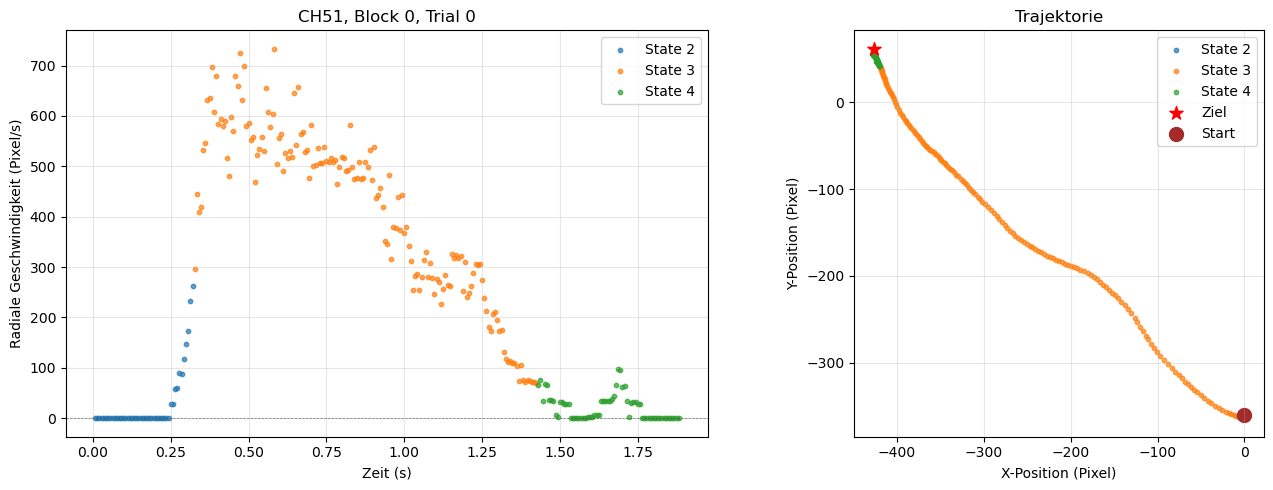


 Statistik für CH51, Block 0, Trial 0:
  Mittlere v_radial: 250.32 Pixel/s
  Maximale v_radial: 733.26 Pixel/s
  Minimale v_radial: 0.00 Pixel/s


In [79]:
# Alle verfügbaren Trials
all_trials = df_reaching_clean[['Participant', 'block', 'trial']].drop_duplicates().sort_values(['Participant', 'block', 'trial']).reset_index(drop=True)
current_idx = 0

def plot_trial(idx):
    row = all_trials.iloc[idx]
    participant = row['Participant']
    block = row['block']
    trial = row['trial']
    
    # Daten filtern
    df_filtered = df_reaching_clean[
        (df_reaching_clean['Participant'] == participant) &
        (df_reaching_clean['block'] == block) &
        (df_reaching_clean['trial'] == trial)
    ]
    
    if df_filtered.empty:
        print(f"Keine Daten für {participant}, Block {block}, Trial {trial}")
        return
    
    # Plot erstellen
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
    
    # Plot 1: Radiale Geschwindigkeit über Zeit (geglättet)
    for marker in sorted(df_filtered['state_marker'].unique()):
        mask = df_filtered['state_marker'] == marker
        ax1.scatter(
            df_filtered.loc[mask, 'time_rel'], 
            df_filtered.loc[mask, 'v_radial'],
            label=f'State {marker}',
            alpha=0.7,
            s=10
        )
    ax1.axhline(y=0, color='black', linestyle='--', alpha=0.5, linewidth=0.5)
    ax1.set_xlabel('Zeit (s)')
    ax1.set_ylabel('Radiale Geschwindigkeit (Pixel/s)')
    ax1.set_title(f'{participant}, Block {block}, Trial {trial}')
    ax1.legend()
    ax1.grid(True, alpha=0.3)
    
    # Plot 2: Trajektorie
    for marker in sorted(df_filtered['state_marker'].unique()):
        mask = df_filtered['state_marker'] == marker
        ax2.scatter(
            df_filtered.loc[mask, 'cursor_x_smooth'], 
            df_filtered.loc[mask, 'cursor_y_smooth'],
            label=f'State {marker}',
            alpha=0.7,
            s=10
        )
    ax2.scatter([df_filtered['target_x'].iloc[0]], [df_filtered['target_y'].iloc[0]], 
                color='red', s=100, marker='*', label='Ziel')
    # Fester Startpunkt aus dem Experiment (params.py)
    start_x = 0      # STARTING_POINT_POS[0]
    start_y = -360   # STARTING_POINT_POS[1]
    ax2.scatter([start_x], [start_y], color='brown', s=100, marker='o', label='Start')
    ax2.set_xlabel('X-Position (Pixel)')
    ax2.set_ylabel('Y-Position (Pixel)')
    ax2.set_title('Trajektorie')
    ax2.legend()
    ax2.grid(True, alpha=0.3)
    ax2.set_aspect('equal')
    
    plt.tight_layout()
    plt.show()
    plt.close(fig)
    
    # Statistik anzeigen
    print(f"\n Statistik für {participant}, Block {block}, Trial {trial}:")
    print(f"  Mittlere v_radial: {df_filtered['v_radial'].mean():.2f} Pixel/s")
    print(f"  Maximale v_radial: {df_filtered['v_radial'].max():.2f} Pixel/s")
    print(f"  Minimale v_radial: {df_filtered['v_radial'].min():.2f} Pixel/s")

# Next/Previous Buttons
def next_trial(b):
    global current_idx
    current_idx = min(current_idx + 1, len(all_trials) - 1)
    plot_trial(current_idx)

def prev_trial(b):
    global current_idx
    current_idx = max(current_idx - 1, 0)
    plot_trial(current_idx)

# Dropdowns für Navigation
participant_dropdown = widgets.Dropdown(
    options=sorted(df_reaching_clean['Participant'].unique()),
    description='Participant:'
)

block_dropdown = widgets.Dropdown(
    options=sorted(df_reaching_clean['block'].unique()),
    description='Block:'
)

trial_dropdown = widgets.Dropdown(
    options=sorted(df_reaching_clean[df_reaching_clean['Participant'] == participant_dropdown.value]['trial'].unique()),
    description='Trial:'
)

def update_trials(change):
    block_dropdown.options = sorted(df_reaching_clean[df_reaching_clean['Participant'] == change.new]['block'].unique())
    trial_dropdown.options = sorted(df_reaching_clean[
        (df_reaching_clean['Participant'] == change.new) & 
        (df_reaching_clean['block'] == block_dropdown.value)
    ]['trial'].unique())

participant_dropdown.observe(update_trials, names='value')

def on_go_button(b):
    global current_idx
    mask = (all_trials['Participant'] == participant_dropdown.value) & \
           (all_trials['block'] == block_dropdown.value) & \
           (all_trials['trial'] == trial_dropdown.value)
    if mask.any():
        current_idx = all_trials[mask].index[0]
        plot_trial(current_idx)

# Buttons
prev_btn = widgets.Button(description='◀ Previous')
next_btn = widgets.Button(description='Next ▶')
go_btn = widgets.Button(description='Go', button_style='success')

prev_btn.on_click(prev_trial)
next_btn.on_click(next_trial)
go_btn.on_click(on_go_button)

# Layout
controls = widgets.HBox([
    prev_btn,
    participant_dropdown,
    block_dropdown,
    trial_dropdown,
    go_btn,
    next_btn
])

display(controls)

# Ersten Trial anzeigen
plot_trial(0)

Jetzt nur die Statemarker der direkten Experiments

In [80]:
from IPython.display import display, clear_output
import matplotlib.pyplot as plt
from ipywidgets import widgets

# Alle verfügbaren Trials
all_trials = df_reaching_clean[['Participant', 'block', 'trial']].drop_duplicates().sort_values(['Participant', 'block', 'trial']).reset_index(drop=True)
current_idx = 0

output = widgets.Output()

def plot_trial(idx):
    output.clear_output(wait=True)
    with output:
        try:
            row = all_trials.iloc[idx]
            participant = row['Participant']
            block = row['block']
            trial = row['trial']

            df_filtered = df_reaching_clean[
                (df_reaching_clean['Participant'] == participant) &
                (df_reaching_clean['block'] == block) &
                (df_reaching_clean['trial'] == trial)
            ].copy()

            df_filtered = df_filtered[df_filtered['state_marker'].isin([2, 3, 4])]

            if df_filtered.empty:
                print(f"Keine Daten für {participant}, Block {block}, Trial {trial} (State 2-4)")
                return

            fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

            for marker in sorted(df_filtered['state_marker'].unique()):
                mask = df_filtered['state_marker'] == marker
                ax1.scatter(df_filtered.loc[mask, 'time_rel'],
                            df_filtered.loc[mask, 'v_radial'],
                            label=f'State {marker}', alpha=0.7, s=10)
            ax1.axhline(y=0, color='black', linestyle='--', alpha=0.5, linewidth=0.5)
            y_min = -750
            y_max = df_filtered['v_radial'].max()
            y_padding = abs(y_max) * 0.2 if y_max > 0 else 100
            ax1.set_ylim(y_min, y_max + y_padding)
            ax1.set_xlabel('Zeit (s)')
            ax1.set_ylabel('Radiale Geschwindigkeit (Pixel/s)')
            ax1.set_title(f'{participant}, Block {block}, Trial {trial} (State 2-4)')
            ax1.legend()
            ax1.grid(True, alpha=0.3)

            for marker in sorted(df_filtered['state_marker'].unique()):
                mask = df_filtered['state_marker'] == marker
                ax2.scatter(df_filtered.loc[mask, 'cursor_x_smooth'],
                            df_filtered.loc[mask, 'cursor_y_smooth'],
                            label=f'State {marker}', alpha=0.7, s=10)
            ax2.scatter([df_filtered['target_x'].iloc[0]], [df_filtered['target_y'].iloc[0]],
                        color='red', s=100, marker='*', label='Ziel')
            ax2.scatter([0], [-360], color='brown', s=100, marker='o', label='Start')
            ax2.set_xlabel('X-Position (Pixel)')
            ax2.set_ylabel('Y-Position (Pixel)')
            ax2.set_title('Trajektorie (State 2-4)')
            ax2.legend()
            ax2.grid(True, alpha=0.3)
            ax2.set_aspect('equal')

            plt.tight_layout()
            display(fig)          # ⬅️ Wichtig: display() statt plt.show()
            plt.close(fig)

            cm_per_pixel = 59.7 / 2560
            mean_cm_s = df_filtered['v_radial'].mean() * cm_per_pixel
            max_cm_s = df_filtered['v_radial'].max() * cm_per_pixel
            min_cm_s = df_filtered['v_radial'].min() * cm_per_pixel

            print(f"\n📊 Statistik für {participant}, Block {block}, Trial {trial} (State 2-4):")
            print(f"  Mittlere v_radial: {df_filtered['v_radial'].mean():.2f} Pixel/s  ({mean_cm_s:.2f} cm/s)")
            print(f"  Maximale v_radial: {df_filtered['v_radial'].max():.2f} Pixel/s  ({max_cm_s:.2f} cm/s)")
            print(f"  Minimale v_radial: {df_filtered['v_radial'].min():.2f} Pixel/s  ({min_cm_s:.2f} cm/s)")
            print(f"  Anzahl Samples: {len(df_filtered)}")

        except Exception as e:
            print(f"❌ Fehler beim Plotten: {e}")

# --- Navigation ---
def next_trial(b):
    global current_idx
    current_idx = min(current_idx + 1, len(all_trials) - 1)
    plot_trial(current_idx)

def prev_trial(b):
    global current_idx
    current_idx = max(current_idx - 1, 0)
    plot_trial(current_idx)

# --- Dropdowns mit initialer Befüllung ---
participants = sorted(df_reaching_clean['Participant'].unique())

participant_dropdown = widgets.Dropdown(
    options=participants,
    description='Participant:',
    disabled=False
)

block_dropdown = widgets.Dropdown(
    options=[],                # wird sofort gefüllt
    description='Block:',
    disabled=False
)

trial_dropdown = widgets.Dropdown(
    options=[],                # wird sofort gefüllt
    description='Trial:',
    disabled=False
)

# Event-Handler: Blöcke und Trials aktualisieren, wenn Teilnehmer wechselt
def update_blocks_and_trials(change):
    participant = change.new
    blocks = sorted(df_reaching_clean[df_reaching_clean['Participant'] == participant]['block'].unique())
    block_dropdown.options = blocks
    if blocks:
        # Falls der alte Wert nicht mehr vorhanden ist, nimm den ersten Block
        if block_dropdown.value not in blocks:
            block_dropdown.value = blocks[0]
        # value-Änderung löst automatisch update_trials aus
    else:
        trial_dropdown.options = []

# Event-Handler: Trials aktualisieren, wenn Block wechselt
def update_trials(change):
    block = change.new
    participant = participant_dropdown.value
    if participant is None or block is None:
        trial_dropdown.options = []
        return
    trials = sorted(df_reaching_clean[
        (df_reaching_clean['Participant'] == participant) &
        (df_reaching_clean['block'] == block)
    ]['trial'].unique())
    trial_dropdown.options = trials
    if trials:
        if trial_dropdown.value not in trials:
            trial_dropdown.value = trials[0]
    else:
        trial_dropdown.options = []

participant_dropdown.observe(update_blocks_and_trials, names='value')
block_dropdown.observe(update_trials, names='value')

def on_go_button(b):
    global current_idx
    p = participant_dropdown.value
    bl = block_dropdown.value
    tr = trial_dropdown.value
    if None in (p, bl, tr):
        with output:
            print("Bitte alle Dropdowns auswählen.")
        return
    mask = (all_trials['Participant'] == p) & (all_trials['block'] == bl) & (all_trials['trial'] == tr)
    if mask.any():
        current_idx = all_trials[mask].index[0]
        plot_trial(current_idx)
    else:
        with output:
            print("Kein passender Trial gefunden.")

# Buttons
prev_btn = widgets.Button(description='◀ Previous')
next_btn = widgets.Button(description='Next ▶')
go_btn = widgets.Button(description='Go', button_style='success')
prev_btn.on_click(prev_trial)
next_btn.on_click(next_trial)
go_btn.on_click(on_go_button)

# --- Startwerte setzen (damit Dropdowns sofort gefüllt sind) ---
if participants:
    participant_dropdown.value = participants[0]   # löst update_blocks_and_trials aus
else:
    with output:
        print("Keine Teilnehmerdaten.")

controls = widgets.HBox([prev_btn, participant_dropdown, block_dropdown, trial_dropdown, go_btn, next_btn])
display(controls)
display(output)

# Ersten Trial anzeigen
if len(all_trials) > 0:
    plot_trial(0)
else:
    with output:
        print("Keine Trials vorhanden.")

Output()

Velocity graph als line plot

Review cut of point for positive velocity -> graph gets cut of in many trials

In [81]:
# Alle verfügbaren Trials holen
all_trials = df_reaching_clean[['Participant', 'block', 'trial']].drop_duplicates().sort_values(['Participant', 'block', 'trial']).reset_index(drop=True)
current_idx = 0

output = widgets.Output()

def plot_trial(idx):
    # Alte Figuren schließen, um Speicher zu sparen
    plt.close('all')
    output.clear_output(wait=True)
    
    with output:
        try:
            row = all_trials.iloc[idx]
            participant = row['Participant']
            block = row['block']
            trial = row['trial']
            
            # Daten filtern (Nur die aktiven Bewegungs-States 2, 3, 4)
            df_filtered = df_reaching_clean[
                (df_reaching_clean['Participant'] == participant) &
                (df_reaching_clean['block'] == block) &
                (df_reaching_clean['trial'] == trial) &
                (df_reaching_clean['state_marker'].isin([2, 3, 4]))
            ].copy()
            
            if df_filtered.empty:
                print(f"Keine Daten für {participant}, Block {block}, Trial {trial} (State 2-4)")
                return
                
            # ========================================================
            # BERECHNUNG DER GAZE-KINEMATIK (ON THE FLY FÜR DEN PLOT)
            # ========================================================
            df_filtered['gaze_x_smooth'] = df_filtered['gaze_x'].rolling(5, center=True, min_periods=1).mean()
            df_filtered['gaze_y_smooth'] = df_filtered['gaze_y'].rolling(5, center=True, min_periods=1).mean()
            
            target_x = df_filtered['target_x'].iloc[0]
            target_y = df_filtered['target_y'].iloc[0]
            start_gaze_x = df_filtered['gaze_x'].iloc[0]
            start_gaze_y = df_filtered['gaze_y'].iloc[0]
            
            dist = np.sqrt((target_x - start_gaze_x)**2 + (target_y - start_gaze_y)**2)
            ux = (target_x - start_gaze_x) / dist if dist != 0 else 0
            uy = (target_y - start_gaze_y) / dist if dist != 0 else 0
            
            df_filtered['dt_gaze'] = df_filtered['time'].diff()
            df_filtered['dx_gaze'] = df_filtered['gaze_x_smooth'].diff()
            df_filtered['dy_gaze'] = df_filtered['gaze_y_smooth'].diff()
            
            df_filtered['vx_gaze'] = df_filtered['dx_gaze'] / df_filtered['dt_gaze']
            df_filtered['vy_gaze'] = df_filtered['dy_gaze'] / df_filtered['dt_gaze']
            
            df_filtered['v_radial_gaze'] = df_filtered['vx_gaze'] * ux + df_filtered['vy_gaze'] * uy
            df_filtered.loc[df_filtered['v_radial_gaze'].abs() > 2000, 'v_radial_gaze'] = np.nan

            # ========================================================
            # PLOTTING (2 ZEILEN, 2 SPALTEN)
            # ========================================================
            fig, axes = plt.subplots(2, 2, figsize=(15, 10))
            
            ax_cur_vel  = axes[0, 0]
            ax_cur_path = axes[0, 1]
            ax_gaze_vel = axes[1, 0]
            ax_gaze_path= axes[1, 1]
            
            # --- 1. CURSOR VELOCITY ---
            ax_cur_vel.plot(df_filtered['time_rel'], df_filtered['v_radial'], 
                            color='blue', linestyle='-', linewidth=2, label='Cursor Velocity')
            ax_cur_vel.axhline(y=0, color='black', linestyle='--', alpha=0.5, linewidth=0.5)
            ax_cur_vel.set_xlabel('Zeit relativ (s)')
            ax_cur_vel.set_ylabel('Geschwindigkeit (Pixel/s)')
            ax_cur_vel.set_title(f'Cursor Velocity: {participant}, Block {block}, Trial {trial}')
            ax_cur_vel.grid(True, alpha=0.3)
            ax_cur_vel.legend()
            
            # --- 2. CURSOR TRAJECTORY ---
            ax_cur_path.scatter(df_filtered['cursor_x_smooth'], df_filtered['cursor_y_smooth'],
                                color='blue', alpha=0.6, s=15, label='Cursor Path')
            ax_cur_path.scatter([target_x], [target_y], color='red', s=150, marker='*', label='Target', zorder=5)
            ax_cur_path.scatter([0], [-360], color='brown', s=100, marker='o', label='Start', zorder=5)
            ax_cur_path.set_xlabel('X-Position (Pixel)')
            ax_cur_path.set_ylabel('Y-Position (Pixel)')
            ax_cur_path.set_title('Cursor Trajectory')
            ax_cur_path.legend()
            ax_cur_path.grid(True, alpha=0.3)
            ax_cur_path.set_aspect('equal')
            
            # --- 3. GAZE VELOCITY ---
            ax_gaze_vel.plot(df_filtered['time_rel'], df_filtered['v_radial_gaze'], 
                            color='green', linestyle='-', linewidth=1.5, alpha=0.8, label='Gaze Velocity')
            ax_gaze_vel.axhline(y=0, color='black', linestyle='--', alpha=0.5, linewidth=0.5)
            ax_gaze_vel.set_xlabel('Zeit relativ (s)')
            ax_gaze_vel.set_ylabel('Geschwindigkeit (Pixel/s)')
            ax_gaze_vel.set_title('Gaze Velocity Profile')
            ax_gaze_vel.grid(True, alpha=0.3)
            ax_gaze_vel.legend()
            
            # --- 4. GAZE TRAJECTORY ---
            ax_gaze_path.scatter(df_filtered['gaze_x_smooth'], df_filtered['gaze_y_smooth'],
                                 color='green', alpha=0.4, s=10, label='Gaze Path')
            ax_gaze_path.scatter([target_x], [target_y], color='red', s=150, marker='*', label='Target', zorder=5)
            ax_gaze_path.scatter([0], [-360], color='brown', s=100, marker='o', label='Start', zorder=5)
            ax_gaze_path.set_xlabel('X-Position (Pixel)')
            ax_gaze_path.set_ylabel('Y-Position (Pixel)')
            ax_gaze_path.set_title('Gaze Trajectory')
            ax_gaze_path.legend()
            ax_gaze_path.grid(True, alpha=0.3)
            ax_gaze_path.set_aspect('equal')
            
            plt.tight_layout()
            # -----------------------------------------
            # 🔧 REPARIERT: display() statt plt.show()
            # -----------------------------------------
            display(fig)
            plt.close(fig)
        
        except Exception as e:
            print(f"❌ Fehler beim Plotten: {e}")

# --- Navigation ---
def next_trial(b):
    global current_idx
    current_idx = min(current_idx + 1, len(all_trials) - 1)
    plot_trial(current_idx)

def prev_trial(b):
    global current_idx
    current_idx = max(current_idx - 1, 0)
    plot_trial(current_idx)

# --- Dropdowns mit korrekter Abhängigkeit ---
participants = sorted(df_reaching_clean['Participant'].unique())

participant_dropdown = widgets.Dropdown(
    options=participants,
    description='Participant:',
    disabled=False
)

block_dropdown = widgets.Dropdown(
    options=[],   # wird dynamisch gefüllt
    description='Block:',
    disabled=False
)

trial_dropdown = widgets.Dropdown(
    options=[],   # wird dynamisch gefüllt
    description='Trial:',
    disabled=False
)

def update_blocks_and_trials(change):
    """Wenn der Teilnehmer wechselt, Blöcke neu laden und Trials aktualisieren."""
    participant = change.new
    if participant is None:
        return
    blocks = sorted(df_reaching_clean[df_reaching_clean['Participant'] == participant]['block'].unique())
    block_dropdown.options = blocks
    if blocks:
        # Falls der alte Block nicht mehr vorhanden, den ersten nehmen
        if block_dropdown.value not in blocks:
            block_dropdown.value = blocks[0]
        # Die value-Änderung löst automatisch update_trials aus
    else:
        trial_dropdown.options = []

def update_trials(change):
    """Wenn der Block wechselt, Trials neu laden."""
    block = change.new
    participant = participant_dropdown.value
    if participant is None or block is None:
        trial_dropdown.options = []
        return
    trials = sorted(df_reaching_clean[
        (df_reaching_clean['Participant'] == participant) &
        (df_reaching_clean['block'] == block)
    ]['trial'].unique())
    trial_dropdown.options = trials
    if trials:
        if trial_dropdown.value not in trials:
            trial_dropdown.value = trials[0]
    else:
        trial_dropdown.options = []

participant_dropdown.observe(update_blocks_and_trials, names='value')
block_dropdown.observe(update_trials, names='value')

def on_go_button(b):
    global current_idx
    p = participant_dropdown.value
    bl = block_dropdown.value
    tr = trial_dropdown.value
    if None in (p, bl, tr):
        with output:
            print("Bitte alle Dropdowns auswählen.")
        return
    mask = (all_trials['Participant'] == p) & (all_trials['block'] == bl) & (all_trials['trial'] == tr)
    if mask.any():
        current_idx = all_trials[mask].index[0]
        plot_trial(current_idx)
    else:
        with output:
            print("Kein passender Trial gefunden.")

# Buttons
prev_btn = widgets.Button(description='◀ Previous')
next_btn = widgets.Button(description='Next ▶')
go_btn = widgets.Button(description='Go', button_style='success')

prev_btn.on_click(prev_trial)
next_btn.on_click(next_trial)
go_btn.on_click(on_go_button)

# --- Startwerte setzen (damit Dropdowns sofort befüllt sind) ---
if participants:
    participant_dropdown.value = participants[0]  # löst update_blocks_and_trials aus
else:
    with output:
        print("Keine Teilnehmerdaten.")

# Layout anzeigen
controls = widgets.HBox([prev_btn, participant_dropdown, block_dropdown, trial_dropdown, go_btn, next_btn])
display(controls)
display(output)

# Ersten Trial rendern
if len(all_trials) > 0:
    plot_trial(0)
else:
    with output:
        print("Keine Trials vorhanden.")

Output()

Tabelle mit den werten:

In [82]:
metrics_list = []

for (participant, trial, block), group in df_reaching_clean.groupby(['Participant', 'trial', 'block']):
    try:
        # Relative Zeit für den GESAMTEN Trial
        time_rel_full = group['time'] - group['time'].iloc[0]
        
        # Nur State 2-4 für Metriken
        group_motion = group[group['state_marker'].isin([2, 3, 4])].copy()
        blob_width = group['blob_width'].iloc[0]
        
        # Standardwerte
        latency = peak = duration = quick_phase = slow_phase = pos_error = precision = np.nan
        
        if not group_motion.empty:
            # Relative Zeit für State 2-4 (basierend auf Trial-Beginn)
            time_rel = group_motion['time'] - group['time'].iloc[0]  # <-- HIER GEÄNDERT
            
            # Latenz
            mask = group_motion['v_radial'].fillna(0) > 10
            if mask.any():
                latency = time_rel[mask].iloc[0]
                t0 = latency
                t_peak = time_rel[group_motion['v_radial'].idxmax()]
                first_state4 = group_motion[group_motion['state_marker'] == 4].iloc[0]
                t_end = time_rel[first_state4.name]  # Zeitpunkt des ersten Frames in State 4
                duration = t_end - t0
                quick_phase = t_peak - t0
                slow_phase = t_end - t_peak
            else:
                latency = duration = quick_phase = slow_phase = np.nan
            
            # Peak velocity
            peak = group_motion['v_radial'].max()
            
            # Position error
            last = group_motion.iloc[-1]
            target_x = group_motion['target_x'].iloc[0]
            target_y = group_motion['target_y'].iloc[0]
            pos_error = np.sqrt((last['cursor_x_smooth'] - target_x)**2 +
                                (last['cursor_y_smooth'] - target_y)**2)
            
            # Precision (State 4)
            df_state4 = group_motion[group_motion['state_marker'] == 4]
            if len(df_state4) > 5:
                precision = np.std(df_state4['cursor_x_smooth'])**2 + np.std(df_state4['cursor_y_smooth'])**2
            else:
                precision = np.nan
    except Exception as e:
        print(f"Fehler bei {participant}, Block {block}, Trial {trial}: {e}")
        blob_width = group['blob_width'].iloc[0]
        latency = peak = duration = quick_phase = slow_phase = pos_error = precision = np.nan
    
    metrics_list.append({
        'Participant': participant,
        'trial': trial,
        'block': block,
        'blob_width': blob_width,
        'latency_cursor': latency,
        'peak_velocity_cursor': peak,
        'duration_cursor': duration,
        'quick_phase_cursor': quick_phase,
        'slow_phase_cursor': slow_phase,
        'position_error_cursor': pos_error,
        'precision_cursor': precision,
    })

df_metrics_all = pd.DataFrame(metrics_list)

df_metrics_all = pd.DataFrame(metrics_list)
print(df_metrics_all.groupby('blob_width').size())

# DataFrame erstellen
df_metrics_all = pd.DataFrame(metrics_list)

# Anzahl Trials pro blob_width anzeigen
print("Anzahl Trials pro blob_width:")
print(df_metrics_all.groupby('blob_width').size())

# Aggregation
metric_cols = [col for col in df_metrics_all.columns 
               if col not in ['Participant', 'block', 'trial', 'blob_width']]

df_agg = df_metrics_all.groupby('blob_width')[metric_cols].agg(['mean', 'std'])
df_agg.columns = ['_'.join(col).strip() for col in df_agg.columns.values]

# Ausgabe als CSV
output_dir = Path("metrics_output")
output_dir.mkdir(exist_ok=True)

df_agg.to_csv(output_dir / "metrics_by_blobwidth.csv")
df_metrics_all.to_csv(output_dir / "trial_metrics_raw.csv", index=False)

print("\n--- Aggregierte Metriken pro Blob-Width ---")
from IPython.display import display
display(df_agg.round(2))

blob_width
0.15    240
0.30    240
0.45    240
0.60    240
dtype: int64
Anzahl Trials pro blob_width:
blob_width
0.15    240
0.30    240
0.45    240
0.60    240
dtype: int64

--- Aggregierte Metriken pro Blob-Width ---


,latency_cursor_mean,latency_cursor_std,peak_velocity_cursor_mean,peak_velocity_cursor_std,duration_cursor_mean,duration_cursor_std,quick_phase_cursor_mean,quick_phase_cursor_std,slow_phase_cursor_mean,slow_phase_cursor_std,position_error_cursor_mean,position_error_cursor_std,precision_cursor_mean,precision_cursor_std
blob_width,,,,,,,,,,,,,,
0.15,0.23,0.13,1464.18,557.32,0.65,0.24,0.28,0.17,0.38,0.19,6.20,4.23,45.40,35.43
0.30,0.26,0.15,1549.83,528.74,0.60,0.22,0.27,0.15,0.33,0.16,7.63,5.10,89.88,66.46
0.45,0.25,0.12,1487.14,556.62,0.57,0.21,0.27,0.14,0.30,0.15,9.22,8.88,154.51,103.25
0.60,0.24,0.14,1515.62,508.09,0.55,0.22,0.28,0.16,0.27,0.15,10.00,7.01,238.54,150.09


In [83]:
# Aggregation pro Participant und Blob‑Width
# ------------------------------------------------------------
# Gruppiere nach Participant und blob_width
# Berechne Mittelwert und Standardabweichung für alle metrischen Spalten

# Metrik-Spalten (ohne Identifikatoren)
metric_cols = [col for col in df_metrics_all.columns 
               if col not in ['Participant', 'block', 'trial', 'blob_width']]

# Aggregation: mean und std
df_participant_blob_agg = df_metrics_all.groupby(['Participant', 'blob_width'])[metric_cols].agg(['mean', 'std'])

# Spalten umbenennen: z.B. 'latency_cursor_mean', 'latency_cursor_std'
df_participant_blob_agg.columns = ['_'.join(col).strip() for col in df_participant_blob_agg.columns.values]

# Zurücksetzen des Index, damit Participant und blob_width als Spalten erscheinen
df_participant_blob_agg = df_participant_blob_agg.reset_index()

# ------------------------------------------------------------
# Ausgabe als CSV
# ------------------------------------------------------------
output_dir = Path("metrics_output")
output_dir.mkdir(exist_ok=True)

df_participant_blob_agg.to_csv(output_dir / "metrics_by_participant_blobwidth.csv", index=False)
print(f"Gespeichert: {output_dir / 'metrics_by_participant_blobwidth.csv'}")

# ------------------------------------------------------------
# Anzeige der Tabelle (alle Zeilen)
# ------------------------------------------------------------
from IPython.display import display
print("\n--- Metriken pro Participant und Blob-Width ---")
display(df_participant_blob_agg.round(2))

Gespeichert: metrics_output\metrics_by_participant_blobwidth.csv

--- Metriken pro Participant und Blob-Width ---


,Participant,blob_width,latency_cursor_mean,latency_cursor_std,peak_velocity_cursor_mean,peak_velocity_cursor_std,duration_cursor_mean,duration_cursor_std,quick_phase_cursor_mean,quick_phase_cursor_std,slow_phase_cursor_mean,slow_phase_cursor_std,position_error_cursor_mean,position_error_cursor_std,precision_cursor_mean,precision_cursor_std
0,CH51,0.15,0.22,0.10,1283.68,532.42,0.68,0.18,0.21,0.12,0.47,0.14,6.12,2.72,30.31,23.08
1,CH51,0.30,0.26,0.08,1253.43,647.37,0.58,0.14,0.23,0.13,0.35,0.11,6.70,3.83,63.85,37.07
2,CH51,0.45,0.27,0.09,1095.67,619.65,0.53,0.12,0.23,0.10,0.30,0.12,7.00,2.98,116.26,35.64
3,CH51,0.60,0.30,0.11,1010.15,555.20,0.52,0.15,0.22,0.13,0.30,0.12,7.95,3.36,193.36,69.93
4,DK55,0.15,0.21,0.16,1109.99,586.87,0.44,0.23,0.20,0.13,0.24,0.20,7.41,5.26,58.38,41.30
5,DK55,0.30,0.29,0.16,1250.00,677.62,0.47,0.17,0.18,0.12,0.30,0.18,8.84,4.84,119.21,111.05
6,DK55,0.45,0.27,0.12,1261.08,716.35,0.36,0.17,0.16,0.14,0.20,0.16,9.91,5.51,178.34,135.82
7,DK55,0.60,0.24,0.08,1568.48,545.51,0.33,0.10,0.17,0.10,0.15,0.12,13.15,7.14,268.95,185.57
8,IR31,0.15,0.31,0.11,1801.15,177.56,0.73,0.16,0.34,0.13,0.39,0.09,4.03,2.32,41.60,17.77
9,IR31,0.30,0.42,0.15,1846.80,130.28,0.66,0.14,0.31,0.14,0.35,0.08,4.36,2.33,86.60,40.57


# Dealing with Gaze

In [84]:
# Bildschirmparameter (aus params.py)
SCREEN_WIDTH_CM = 59.7
RESOLUTION_X = 2560
VIEW_DISTANCE_CM = 70
CM_PER_PIXEL = SCREEN_WIDTH_CM / RESOLUTION_X


# ------------------------------------------------------------
# Neue Metrik-Funktion für Gaze (kopiert von Cursor)
# ------------------------------------------------------------

def compute_gaze_metrics_for_trial(trial_data, threshold=10):
    """
    Berechnet Gaze-Metriken für einen Trial (in Pixeln).
    """
    # Nur State 2-4
    df = trial_data[trial_data['state_marker'].isin([2, 3, 4])].copy()
    if df.empty:
        return None
    
    # Zielposition (aus erster Zeile)
    target_x = df['target_x'].iloc[0]
    target_y = df['target_y'].iloc[0]
    
    # Startposition der Gaze (erste Zeile des gesamten Trials)
    start_gaze_x = trial_data['gaze_x'].iloc[0]
    start_gaze_y = trial_data['gaze_y'].iloc[0]
    
    # Einheitsvektor vom Gaze-Start zum Ziel
    dx_target = target_x - start_gaze_x
    dy_target = target_y - start_gaze_y
    dist = np.sqrt(dx_target**2 + dy_target**2)
    ux = dx_target / dist
    uy = dy_target / dist
    
    # Glättung der Gaze-Daten (gleitender Mittelwert)
    df['gaze_x_smooth'] = df['gaze_x'].rolling(10, center=True, min_periods=1).mean()
    df['gaze_y_smooth'] = df['gaze_y'].rolling(10, center=True, min_periods=1).mean()
    
    # Differenzen
    df['dt'] = df['time'].diff()
    df['dx_gaze'] = df['gaze_x_smooth'].diff()
    df['dy_gaze'] = df['gaze_y_smooth'].diff()
    
    # Geschwindigkeitsvektor
    df['vx_gaze'] = df['dx_gaze'] / df['dt']
    df['vy_gaze'] = df['dy_gaze'] / df['dt']
    
    # Radiale Geschwindigkeit
    df['v_radial_gaze'] = df['vx_gaze'] * ux + df['vy_gaze'] * uy
    
    # Ausreißer entfernen
    df.loc[df['v_radial_gaze'].abs() > 2000, 'v_radial_gaze'] = np.nan
    
    # Latenz
    mask = df['v_radial_gaze'].fillna(0) > threshold
    if mask.any():
        time_rel = df['time'] - trial_data['time'].iloc[0]
        latency = time_rel[mask].iloc[0]
        t0 = latency
        t_peak = time_rel[df['v_radial_gaze'].idxmax()]
        # Ersten Frame in State 4
        state4 = df[df['state_marker'] == 4]
        if not state4.empty:
            t_end = state4['time'].iloc[0] - trial_data['time'].iloc[0]
        else:
            t_end = np.nan
        duration = t_end - t0 if not np.isnan(t_end) else np.nan
        quick_phase = t_peak - t0
        slow_phase = t_end - t_peak if not np.isnan(t_end) else np.nan
    else:
        latency = duration = quick_phase = slow_phase = np.nan
    
    peak = df['v_radial_gaze'].max()
    
    # Position error (letzte Gaze-Position)
    last = df.iloc[-1]
    pos_error = np.sqrt((last['gaze_x_smooth'] - target_x)**2 +
                        (last['gaze_y_smooth'] - target_y)**2)
    
    # Precision (State 4)
    df_state4 = df[df['state_marker'] == 4]
    if len(df_state4) > 5:
        precision = np.std(df_state4['gaze_x_smooth'])**2 + np.std(df_state4['gaze_y_smooth'])**2
    else:
        precision = np.nan
    
    return {
        'latency_gaze': latency,
        'peak_velocity_gaze': peak,
        'duration_gaze': duration,
        'quick_phase_gaze': quick_phase,
        'slow_phase_gaze': slow_phase,
        'position_error_gaze': pos_error,
        'precision_gaze': precision,
    }

# ------------------------------------------------------------
# Hauptschleife: Für jeden Trial Cursor- und Gaze-Metriken berechnen
# ------------------------------------------------------------

all_metrics = []

for (participant, trial, block), group in df_reaching_clean.groupby(['Participant', 'trial', 'block']):
    # Cursor-Metriken (bereits vorhanden, wir kopieren sie aus der vorherigen Berechnung)
    # Hier nehmen wir an, dass du bereits df_metrics_all mit Cursor-Metriken hast.
    # Falls nicht, berechne sie hier.
    # Aber um doppelten Code zu vermeiden, holen wir die Cursor-Metriken aus dem vorhandenen DataFrame.
    # Wir führen die Berechnung trotzdem durch, um konsistent zu sein.

    cursor_metrics = compute_cursor_metrics(group)  # deine Funktion
    
    # Gaze-Metriken
    gaze_metrics = compute_gaze_metrics_for_trial(group)
    
    if cursor_metrics is not None and gaze_metrics is not None:
        row = {
            'Participant': participant,
            'trial': trial,
            'block': block,
            'blob_width': group['blob_width'].iloc[0],
            # Cursor
            'latency_cursor': cursor_metrics['latency'],
            'peak_velocity_cursor': cursor_metrics['peak'],
            'duration_cursor': cursor_metrics['duration'],
            'quick_phase_cursor': cursor_metrics['quick_phase'],
            'slow_phase_cursor': cursor_metrics['slow_phase'],
            'position_error_cursor': cursor_metrics['position_error'],
            'precision_cursor': cursor_metrics['precision'],
            # Gaze
            'latency_gaze': gaze_metrics['latency_gaze'],
            'peak_velocity_gaze': gaze_metrics['peak_velocity_gaze'],
            'duration_gaze': gaze_metrics['duration_gaze'],
            'quick_phase_gaze': gaze_metrics['quick_phase_gaze'],
            'slow_phase_gaze': gaze_metrics['slow_phase_gaze'],
            'position_error_gaze': gaze_metrics['position_error_gaze'],
            'precision_gaze': gaze_metrics['precision_gaze'],
        }
        all_metrics.append(row)

df_metrics_all = pd.DataFrame(all_metrics)

# Aggregation nach Participant und blob_width
metric_cols = [col for col in df_metrics_all.columns if col not in ['Participant', 'block', 'trial', 'blob_width']]
df_participant_blob_agg = df_metrics_all.groupby(['Participant', 'blob_width'])[metric_cols].agg(['mean', 'std'])
df_participant_blob_agg.columns = ['_'.join(col).strip() for col in df_participant_blob_agg.columns.values]
df_participant_blob_agg = df_participant_blob_agg.reset_index()

# CSV speichern
output_dir = Path("metrics_output")
output_dir.mkdir(exist_ok=True)
df_participant_blob_agg.to_csv(output_dir / "metrics_by_participant_blobwidth_with_gaze.csv", index=False)
df_metrics_all.to_csv(output_dir / "trial_metrics_raw_with_gaze.csv", index=False)

print("CSV-Dateien mit Gaze-Metriken gespeichert.")
print("\n--- Aggregierte Metriken (mit Gaze) ---")
display(df_participant_blob_agg.round(2))

CSV-Dateien mit Gaze-Metriken gespeichert.

--- Aggregierte Metriken (mit Gaze) ---


,Participant,blob_width,latency_cursor_mean,latency_cursor_std,peak_velocity_cursor_mean,peak_velocity_cursor_std,duration_cursor_mean,duration_cursor_std,quick_phase_cursor_mean,quick_phase_cursor_std,...,duration_gaze_mean,duration_gaze_std,quick_phase_gaze_mean,quick_phase_gaze_std,slow_phase_gaze_mean,slow_phase_gaze_std,position_error_gaze_mean,position_error_gaze_std,precision_gaze_mean,precision_gaze_std
0,CH51,0.15,0.22,0.10,1283.68,532.42,0.68,0.18,0.21,0.12,...,0.87,0.16,0.22,0.08,0.65,0.18,36.08,21.99,51.80,37.11
1,CH51,0.30,0.26,0.08,1253.43,647.37,0.58,0.14,0.23,0.13,...,0.82,0.13,0.21,0.08,0.61,0.13,38.70,17.20,39.95,36.32
2,CH51,0.45,0.27,0.09,1095.67,619.65,0.53,0.12,0.23,0.10,...,0.79,0.08,0.24,0.06,0.55,0.09,41.90,28.30,54.61,42.59
3,CH51,0.60,0.30,0.11,1010.15,555.20,0.52,0.15,0.22,0.13,...,0.80,0.09,0.27,0.08,0.52,0.12,43.31,28.07,81.39,155.55
4,DK55,0.15,0.21,0.16,1109.99,586.87,0.44,0.23,0.20,0.13,...,0.63,0.12,0.17,0.07,0.47,0.13,29.51,14.93,46.25,65.92
5,DK55,0.30,0.29,0.16,1250.00,677.62,0.47,0.17,0.18,0.12,...,0.75,0.08,0.18,0.08,0.57,0.11,40.13,17.83,31.14,31.40
6,DK55,0.45,0.27,0.12,1261.08,716.35,0.36,0.17,0.16,0.14,...,0.61,0.10,0.18,0.07,0.43,0.11,34.69,21.52,62.53,71.22
7,DK55,0.60,0.24,0.08,1568.48,545.51,0.33,0.10,0.17,0.10,...,0.53,0.11,0.17,0.12,0.35,0.16,25.20,14.82,139.74,169.35
8,IR31,0.15,0.31,0.11,1801.15,177.56,0.73,0.16,0.34,0.13,...,1.03,0.09,0.23,0.08,0.80,0.11,50.19,10.21,19.58,20.50
9,IR31,0.30,0.42,0.15,1846.80,130.28,0.66,0.14,0.31,0.14,...,1.06,0.09,0.21,0.08,0.84,0.14,46.64,7.58,13.05,9.03
